# Problema de Ruteo de Vehículos (VRP)

## Modelo de Redes de Transporte y Simulación Logística

En esta práctica se resolverá un **Problema de Ruteo de Vehículos con Capacidad (Capacitated Vehicle Routing Problem, CVRP)**.

Una empresa dispone de un Centro de Distribución (CEDIS), varios clientes con diferentes demandas y una flota limitada de vehículos.

El objetivo será determinar las rutas de distribución que permitan atender a todos los clientes respetando la capacidad de los vehículos y minimizando la distancia total recorrida.

## 1. Del TSP al VRP

En el Problema del Agente Viajero (TSP) se buscaba determinar el mejor recorrido para **un vehículo** que debía visitar todos los clientes.

En el VRP aparecen nuevas decisiones:

- ¿Qué vehículo atenderá a cada cliente?
- ¿Qué clientes deben agruparse en una misma ruta?
- ¿En qué orden deben visitarse?
- ¿Se respeta la capacidad de cada vehículo?

Por lo tanto, el VRP combina problemas de **asignación y ruteo**.

In [1]:
# !pip install ortools

import math
import pandas as pd
import matplotlib.pyplot as plt
from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2

# 2. Definición del problema

Una empresa debe atender ocho clientes desde un único CEDIS.

La empresa dispone de:

- **3 vehículos**
- **15 toneladas de capacidad por vehículo**
- **8 clientes**
- **34 toneladas de demanda total**

Cada cliente tiene una ubicación representada mediante coordenadas `(X,Y)` y una demanda determinada.

In [2]:
coordenadas={"CEDIS":(5,5),"A":(2,8),"B":(3,10),"C":(7,9),"D":(9,8),"E":(10,4),"F":(8,2),"G":(4,1),"H":(1,3)}
demanda={"CEDIS":0,"A":4,"B":3,"C":5,"D":4,"E":6,"F":3,"G":5,"H":4}
numero_vehiculos=3
capacidad_vehiculo=15

datos=pd.DataFrame({"Nodo":list(coordenadas.keys()),"X":[coordenadas[n][0] for n in coordenadas],"Y":[coordenadas[n][1] for n in coordenadas],"Demanda":[demanda[n] for n in coordenadas]})
datos

,Nodo,X,Y,Demanda
0,CEDIS,5,5,0
1,A,2,8,4
2,B,3,10,3
3,C,7,9,5
4,D,9,8,4
5,E,10,4,6
6,F,8,2,3
7,G,4,1,5
8,H,1,3,4


# 3. Análisis de la demanda

Antes de resolver el problema debemos determinar si la flota disponible tiene capacidad suficiente.

La demanda total corresponde a la suma de las demandas de todos los clientes.

El número mínimo teórico de vehículos puede calcularse dividiendo la demanda total entre la capacidad de cada vehículo y redondeando hacia arriba.

In [3]:
demanda_total=sum(demanda.values())
vehiculos_minimos=math.ceil(demanda_total/capacidad_vehiculo)
print("Demanda total:",demanda_total,"toneladas")
print("Capacidad total disponible:",numero_vehiculos*capacidad_vehiculo,"toneladas")
print("Número mínimo teórico de vehículos:",vehiculos_minimos)

Demanda total: 34 toneladas
Capacidad total disponible: 45 toneladas
Número mínimo teórico de vehículos: 3


## Interpretación

La demanda total es de **34 toneladas**.

Cada vehículo tiene capacidad para transportar 15 toneladas.

Dos vehículos únicamente podrían transportar:

**30 toneladas**

Por lo tanto, dos vehículos no son suficientes.

Se requieren como mínimo:

**3 vehículos**

Esto significa que los tres vehículos disponibles serán necesarios para satisfacer completamente la demanda.

# 4. Representación espacial

Antes de construir las rutas podemos representar las ubicaciones de los clientes en un plano.

Esta visualización permite identificar posibles agrupaciones geográficas de clientes.

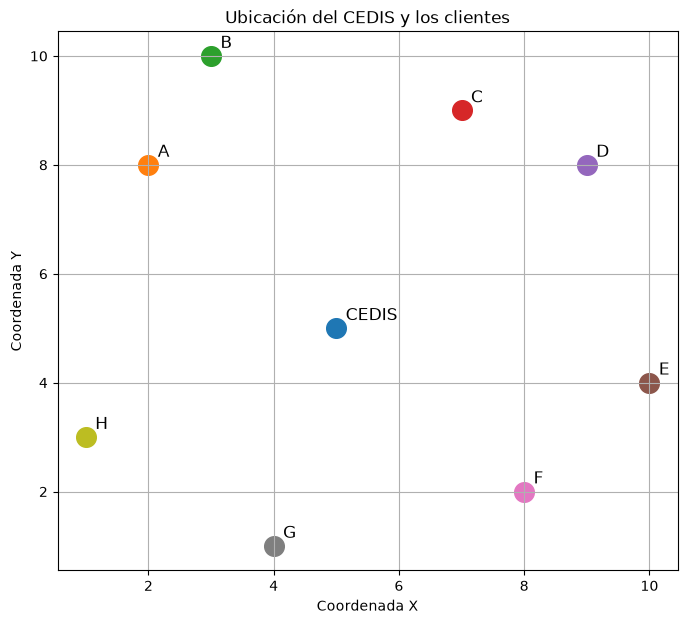

In [4]:
plt.figure(figsize=(8,7))
for nodo,(x,y) in coordenadas.items():
    plt.scatter(x,y,s=200)
    plt.text(x+0.15,y+0.15,nodo,fontsize=12)
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.title("Ubicación del CEDIS y los clientes")
plt.grid()
plt.show()

# 5. Cálculo de distancias

Para este ejercicio utilizaremos la **distancia euclidiana** entre cada par de puntos.

Para dos nodos `i` y `j`:

\[
d_{ij}=\sqrt{(x_j-x_i)^2+(y_j-y_i)^2}
\]

Estas distancias representan una simplificación de las distancias reales de transporte.

En una aplicación real podrían sustituirse por distancias carreteras, tiempos de viaje o costos de transporte.

In [5]:
def distancia(p1,p2):
    return math.sqrt((p2[0]-p1[0])**2+(p2[1]-p1[1])**2)

nodos=list(coordenadas.keys())
matriz_distancias=[]
for origen in nodos:
    fila=[]
    for destino in nodos:
        fila.append(distancia(coordenadas[origen],coordenadas[destino]))
    matriz_distancias.append(fila)
matriz_df=pd.DataFrame(matriz_distancias,index=nodos,columns=nodos)
matriz_df.round(2)

,CEDIS,A,B,C,D,E,F,G,H
CEDIS,0.00,4.24,5.39,4.47,5.00,5.10,4.24,4.12,4.47
A,4.24,0.00,2.24,5.10,7.00,8.94,8.49,7.28,5.10
B,5.39,2.24,0.00,4.12,6.32,9.22,9.43,9.06,7.28
C,4.47,5.10,4.12,0.00,2.24,5.83,7.07,8.54,8.49
D,5.00,7.00,6.32,2.24,0.00,4.12,6.08,8.60,9.43
E,5.10,8.94,9.22,5.83,4.12,0.00,2.83,6.71,9.06
F,4.24,8.49,9.43,7.07,6.08,2.83,0.00,4.12,7.07
G,4.12,7.28,9.06,8.54,8.60,6.71,4.12,0.00,3.61
H,4.47,5.10,7.28,8.49,9.43,9.06,7.07,3.61,0.00


# 6. Solución manual inicial

Durante la clase se propuso inicialmente la siguiente agrupación:

- Vehículo 1: A, B y C
- Vehículo 2: D, E y F
- Vehículo 3: G y H

Antes de utilizar un algoritmo de optimización podemos comprobar si esta asignación respeta las capacidades.

In [6]:
asignacion_manual={1:["A","B","C"],2:["D","E","F"],3:["G","H"]}
for vehiculo,clientes in asignacion_manual.items():
    carga=sum(demanda[c] for c in clientes)
    print(f"Vehículo {vehiculo}: {clientes} | Carga = {carga}/{capacidad_vehiculo} toneladas")

Vehículo 1: ['A', 'B', 'C'] | Carga = 12/15 toneladas
Vehículo 2: ['D', 'E', 'F'] | Carga = 13/15 toneladas
Vehículo 3: ['G', 'H'] | Carga = 9/15 toneladas


La asignación es factible:

| Vehículo | Clientes | Carga |
|---|---|---:|
| 1 | A, B, C | 12 t |
| 2 | D, E, F | 13 t |
| 3 | G, H | 9 t |

Sin embargo, una asignación factible **no necesariamente minimiza la distancia total**.

Ahora utilizaremos OR-Tools para resolver simultáneamente la asignación y el ruteo.

# 7. Preparación de los datos para OR-Tools

OR-Tools trabaja con índices numéricos.

El CEDIS será el nodo `0` y los clientes ocuparán las posiciones restantes.

También convertiremos las distancias a valores enteros multiplicándolas por 100. Esto permite conservar dos decimales durante la optimización.

In [7]:
matriz_ortools=[[int(round(d*100)) for d in fila] for fila in matriz_distancias]
demandas=[demanda[nodo] for nodo in nodos]
capacidades=[capacidad_vehiculo]*numero_vehiculos
deposito=0

# 8. Creación del modelo

El `RoutingIndexManager` administra la relación entre:

- Los nodos del problema.
- Los vehículos.
- El depósito.

Posteriormente se crea el modelo de ruteo.

In [8]:
manager=pywrapcp.RoutingIndexManager(len(matriz_ortools),numero_vehiculos,deposito)
routing=pywrapcp.RoutingModel(manager)

# 9. Función de distancia

OR-Tools necesita conocer el costo de desplazarse entre cada par de nodos.

En este problema el costo será directamente proporcional a la distancia recorrida.

Por lo tanto, minimizar el costo equivale a minimizar la distancia total.

In [9]:
def callback_distancia(indice_origen,indice_destino):
    origen=manager.IndexToNode(indice_origen)
    destino=manager.IndexToNode(indice_destino)
    return matriz_ortools[origen][destino]
indice_distancia=routing.RegisterTransitCallback(callback_distancia)
routing.SetArcCostEvaluatorOfAllVehicles(indice_distancia)

# 10. Restricción de capacidad

Hasta este momento el modelo podría construir rutas sin considerar cuánto transporta cada vehículo.

Para convertirlo en un **CVRP**, debemos agregar:

- Demanda de cada cliente.
- Capacidad máxima de cada vehículo.

La suma de las demandas atendidas por un vehículo no puede superar su capacidad.

In [10]:
def callback_demanda(indice):
    nodo=manager.IndexToNode(indice)
    return demandas[nodo]
indice_demanda=routing.RegisterUnaryTransitCallback(callback_demanda)
routing.AddDimensionWithVehicleCapacity(indice_demanda,0,capacidades,True,"Capacidad")

True

# 11. Estrategia de solución

OR-Tools permite seleccionar diferentes estrategias para construir una solución inicial.

Utilizaremos `PATH_CHEAPEST_ARC`, que comienza construyendo rutas seleccionando conexiones de bajo costo.

Posteriormente aplicaremos una estrategia de búsqueda local para intentar mejorar la solución.

In [11]:
parametros=pywrapcp.DefaultRoutingSearchParameters()
parametros.first_solution_strategy=routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
parametros.local_search_metaheuristic=routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
parametros.time_limit.seconds=5

solucion=routing.SolveWithParameters(parametros)

# 12. Interpretación de la solución

Para cada vehículo mostraremos:

- Clientes visitados.
- Carga transportada.
- Distancia recorrida.

Esto permitirá analizar cómo el algoritmo distribuyó automáticamente los clientes entre los vehículos.

In [12]:
rutas=[]
distancia_total=0
if solucion:
    for vehiculo in range(numero_vehiculos):
        indice=routing.Start(vehiculo)
        ruta=[]
        carga=0
        distancia_ruta=0
        while not routing.IsEnd(indice):
            nodo=manager.IndexToNode(indice)
            ruta.append(nodos[nodo])
            carga+=demandas[nodo]
            indice_anterior=indice
            indice=solucion.Value(routing.NextVar(indice))
            distancia_ruta+=routing.GetArcCostForVehicle(indice_anterior,indice,vehiculo)
        ruta.append("CEDIS")
        distancia_ruta/=100
        distancia_total+=distancia_ruta
        rutas.append(ruta)
        print(f"Vehículo {vehiculo+1}")
        print("Ruta:"," → ".join(ruta))
        print("Carga:",carga,"toneladas")
        print(f"Distancia: {distancia_ruta:.2f}\n")
    print(f"Distancia total: {distancia_total:.2f}")
else:
    print("No se encontró una solución.")

Vehículo 1
Ruta: CEDIS → D → E → F → CEDIS
Carga: 13 toneladas
Distancia: 16.19

Vehículo 2
Ruta: CEDIS → C → B → A → CEDIS
Carga: 12 toneladas
Distancia: 15.07

Vehículo 3
Ruta: CEDIS → G → H → CEDIS
Carga: 9 toneladas
Distancia: 12.20

Distancia total: 43.46


# 13. ¿Qué decidió el algoritmo?

Observe que nosotros únicamente proporcionamos:

- Ubicaciones.
- Distancias.
- Demandas.
- Número de vehículos.
- Capacidad de los vehículos.

No indicamos qué clientes debía atender cada vehículo.

El algoritmo determinó simultáneamente:

1. **Asignación:** qué clientes atiende cada vehículo.
2. **Ruteo:** en qué orden deben visitarse.

Esta es una de las diferencias fundamentales entre resolver varios TSP independientes y resolver un verdadero VRP.

# 14. Visualización de las rutas

Representaremos las rutas obtenidas sobre el plano.

Cada línea representa el recorrido realizado por uno de los vehículos.

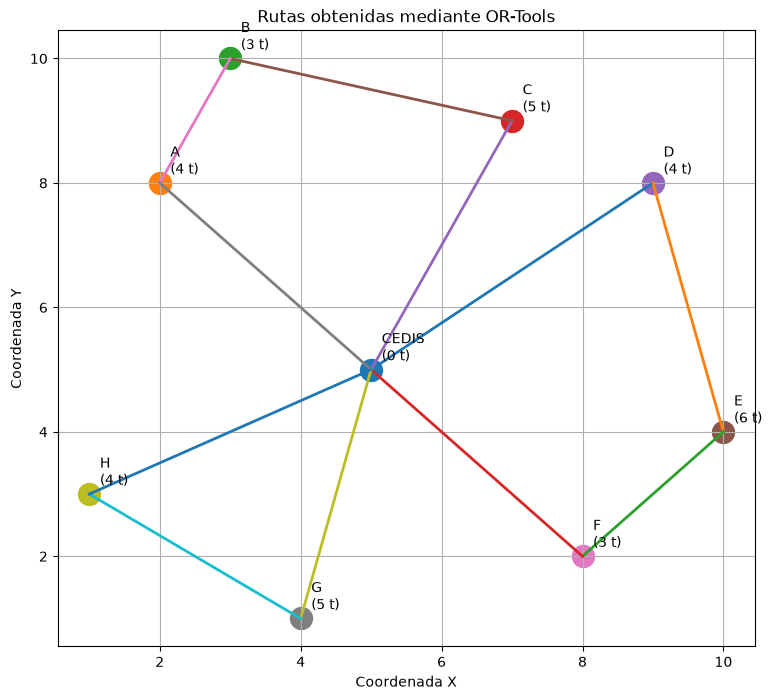

In [13]:
plt.figure(figsize=(9,8))
for nodo,(x,y) in coordenadas.items():
    plt.scatter(x,y,s=250)
    plt.text(x+0.15,y+0.15,f"{nodo}\n({demanda[nodo]} t)",fontsize=10)
for ruta in rutas:
    for i in range(len(ruta)-1):
        x1,y1=coordenadas[ruta[i]]
        x2,y2=coordenadas[ruta[i+1]]
        plt.plot([x1,x2],[y1,y2],linewidth=2)
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.title("Rutas obtenidas mediante OR-Tools")
plt.grid()
plt.show()

# 15. Comparación con la solución manual

Nuestra propuesta manual fue:

**Vehículo 1**

CEDIS → A → B → C → CEDIS

**Vehículo 2**

CEDIS → F → E → D → CEDIS

**Vehículo 3**

CEDIS → G → H → CEDIS

Ahora calcularemos automáticamente la distancia de estas rutas para compararlas contra la solución obtenida mediante OR-Tools.

In [14]:
rutas_manuales=[["CEDIS","A","B","C","CEDIS"],["CEDIS","F","E","D","CEDIS"],["CEDIS","G","H","CEDIS"]]
def calcular_distancia_ruta(ruta):
    total=0
    for i in range(len(ruta)-1):
        total+=distancia(coordenadas[ruta[i]],coordenadas[ruta[i+1]])
    return total
distancia_manual=sum(calcular_distancia_ruta(ruta) for ruta in rutas_manuales)
print(f"Distancia solución manual: {distancia_manual:.2f}")
print(f"Distancia OR-Tools: {distancia_total:.2f}")

mejora=((distancia_manual-distancia_total)/distancia_manual)*100
print(f"Mejora respecto a la solución manual: {mejora:.2f}%")

Distancia solución manual: 43.47
Distancia OR-Tools: 43.46
Mejora respecto a la solución manual: 0.02%


# 16. Experimento: reducción de capacidad

Modifique la capacidad de los vehículos de:

**15 toneladas → 12 toneladas**

Antes de ejecutar nuevamente el modelo, responda:

1. ¿Los tres vehículos continúan siendo suficientes?
2. ¿Cuál es ahora la capacidad total disponible?
3. ¿Cómo espera que cambien las rutas?
4. ¿Será posible mantener las mismas agrupaciones de clientes?

Posteriormente modifique el modelo y compruebe su respuesta.

In [15]:
nueva_capacidad=12
capacidad_total=nueva_capacidad*numero_vehiculos
print("Demanda total:",demanda_total)
print("Nueva capacidad total:",capacidad_total)
print("¿Existe capacidad total suficiente?",capacidad_total>=demanda_total)

Demanda total: 34
Nueva capacidad total: 36
¿Existe capacidad total suficiente? True


# 17. Experimento: incremento de demanda

Suponga ahora que la demanda del Cliente E aumenta:

**6 toneladas → 9 toneladas**

Analice:

1. ¿Cuál es la nueva demanda total?
2. ¿Continúan siendo suficientes tres vehículos?
3. ¿Qué clientes podrían compartir vehículo con E?
4. ¿Cómo podría modificarse la solución?

Modifique los datos y resuelva nuevamente el problema.

# 18. Del CVRP al VRPTW

El modelo utilizado considera principalmente:

- Distancias.
- Demandas.
- Vehículos.
- Capacidades.

Sin embargo, un cliente podría indicar:

**Cliente B: recibir entre 08:00 y 10:00**

**Cliente E: recibir entre 12:00 y 14:00**

Para incorporar estas condiciones sería necesario agregar:

- Tiempo de viaje entre clientes.
- Horario de inicio de cada vehículo.
- Tiempo de servicio.
- Ventanas de tiempo.
- Tiempo máximo de operación.

El problema se convertiría en un:

## Vehicle Routing Problem with Time Windows (VRPTW)

# Actividad

Utilizando el modelo desarrollado:

1. Obtenga las rutas propuestas por OR-Tools.
2. Determine la carga transportada por cada vehículo.
3. Calcule la distancia total.
4. Compare la solución computacional contra la solución manual.
5. Reduzca la capacidad de los vehículos a 12 toneladas y analice el resultado.
6. Aumente la demanda del Cliente E a 9 toneladas y vuelva a resolver el problema.
7. Explique qué información sería necesaria para incorporar ventanas de tiempo.
8. Proponga dos restricciones adicionales que podrían existir en una operación logística real.

# Conclusiones

El Problema de Ruteo de Vehículos representa una extensión del Problema del Agente Viajero hacia situaciones logísticas más realistas.

Mientras que el TSP determina el recorrido de un solo vehículo, el VRP debe determinar simultáneamente:

- Qué vehículo atiende cada cliente.
- Qué clientes forman parte de una misma ruta.
- En qué orden deben visitarse.
- Cómo respetar las restricciones de capacidad.

En aplicaciones reales pueden incorporarse restricciones adicionales relacionadas con horarios, tipos de vehículos, tiempos de servicio, múltiples depósitos, recolecciones, entregas y autonomía.

Por esta razón, el VRP constituye una familia de problemas fundamentales para la optimización de sistemas modernos de distribución y transporte.